<a href="https://colab.research.google.com/github/soujanyapittala/Driver-Attrition-Prediction-Using-Ensemble-Learning/blob/main/Copy_of_Ensemble_Learning_Business_Case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Define Problem Statement and perform Exploratory Data Analysis

##Understand the business problem
**Business objective**

Ola is facing high driver attrition. Recruiting a new driver is more expensive than retaining an existing driver.

**Our objective is therefore**:

Predict whether a driver is likely to leave Ola based on demographic information, tenure, income, business performance, grade, and quarterly rating.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Plotting style
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
df = pd.read_csv('/content/ola_driver_scaler.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

/usr/local/lib/python3.13/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.00,0.00,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.00,0.00,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.00,0.00,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.00,0.00,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.00,0.00,C7,2,67016,11/06/20,NaN,2,2,0,1


In [6]:
# ============================================
# STEP 3: CHECK SHAPE
# ============================================

print("Number of rows    :", df.shape[0])
print("Number of columns :", df.shape[1])

Number of rows    : 19104
Number of columns : 14


In [8]:
print("Total records          :", len(df))
print("Unique drivers         :", df['Driver_ID'].nunique())
print("Average records/driver :", round(len(df) / df['Driver_ID'].nunique(), 2))

Total records          : 19104
Unique drivers         : 2381
Average records/driver : 8.02


###Key insight

Rows    = 19,104
Columns = 14

There are 19,104 observations, but only 2,381 unique drivers.


In [9]:
#Check First and Last Records
# First 5 rows
display(df.head())

# Last 5 rows
display(df.tail())

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.00,0.00,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.00,0.00,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.00,0.00,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.00,0.00,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.00,0.00,C7,2,67016,11/06/20,NaN,2,2,0,1


,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
19099,19099,08/01/20,2788,30.00,0.00,C27,2,70254,06/08/20,NaN,2,2,740280,3
19100,19100,09/01/20,2788,30.00,0.00,C27,2,70254,06/08/20,NaN,2,2,448370,3
19101,19101,10/01/20,2788,30.00,0.00,C27,2,70254,06/08/20,NaN,2,2,0,2
19102,19102,11/01/20,2788,30.00,0.00,C27,2,70254,06/08/20,NaN,2,2,200420,2
19103,19103,12/01/20,2788,30.00,0.00,C27,2,70254,06/08/20,NaN,2,2,411480,2


In [10]:
# ============================================
# STEP 5: DATASET INFORMATION
# ============================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+ MB


In [12]:
# ============================================
# STEP 6: UNIQUE VALUES
# ============================================

for column in df.columns:
    print(f"\n{column}")
    print("Number of unique values:", df[column].nunique())
    print("Sample values:", df[column].dropna().unique()[:10])


Unnamed: 0
Number of unique values: 19104
Sample values: [0 1 2 3 4 5 6 7 8 9]

MMM-YY
Number of unique values: 24
Sample values: ['01/01/19' '02/01/19' '03/01/19' '11/01/20' '12/01/20' '12/01/19'
 '01/01/20' '02/01/20' '03/01/20' '04/01/20']

Driver_ID
Number of unique values: 2381
Sample values: [ 1  2  4  5  6  8 11 12 13 14]

Age
Number of unique values: 36
Sample values: [28. 31. 43. 29. 34. 35. 30. 39. 42. 27.]

Gender
Number of unique values: 2
Sample values: [0. 1.]

City
Number of unique values: 29
Sample values: ['C23' 'C7' 'C13' 'C9' 'C11' 'C2' 'C19' 'C26' 'C20' 'C17']

Education_Level
Number of unique values: 3
Sample values: [2 0 1]

Income
Number of unique values: 2383
Sample values: [ 57387  67016  65603  46368  78728  70656  42172  28116 119227  19734]

Dateofjoining
Number of unique values: 869
Sample values: ['24/12/18' '11/06/20' '12/07/19' '01/09/19' '31/07/20' '19/09/20'
 '12/07/20' '29/06/19' '28/05/15' '16/10/20']

LastWorkingDate
Number of unique values: 493
Sa

In [13]:
# ============================================
# STEP 7: CHECK DUPLICATE ROWS
# ============================================

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


###Insight

There are no completely duplicated records in the raw dataset.

However, don't confuse duplicate Driver_ID.

A driver appearing multiple times is expected, because the data is monthly.

In [14]:
# ============================================
# STEP 8: CONVERT DATE COLUMNS
# ============================================

date_columns = [
    'MMM-YY',
    'Dateofjoining',
    'LastWorkingDate'
]

for column in date_columns:
    df[column] = pd.to_datetime(df[column], dayfirst=True, errors='coerce')

# Check data types
df[date_columns].dtypes

/tmp/ipykernel_2500/1201274704.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column], dayfirst=True, errors='coerce')
/tmp/ipykernel_2500/1201274704.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column], dayfirst=True, errors='coerce')
/tmp/ipykernel_2500/1201274704.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column], dayfirst=True, errors='coerce')


,0
MMM-YY,datetime64[ns]
Dateofjoining,datetime64[ns]
LastWorkingDate,datetime64[ns]


In [15]:
df[date_columns].head()

,MMM-YY,Dateofjoining,LastWorkingDate
0,2019-01-01,2018-12-24,NaT
1,2019-01-02,2018-12-24,NaT
2,2019-01-03,2018-12-24,2019-11-03
3,2020-01-11,2020-06-11,NaT
4,2020-01-12,2020-06-11,NaT


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Unnamed: 0            19104 non-null  int64         
 1   MMM-YY                19104 non-null  datetime64[ns]
 2   Driver_ID             19104 non-null  int64         
 3   Age                   19043 non-null  float64       
 4   Gender                19052 non-null  float64       
 5   City                  19104 non-null  object        
 6   Education_Level       19104 non-null  int64         
 7   Income                19104 non-null  int64         
 8   Dateofjoining         19104 non-null  datetime64[ns]
 9   LastWorkingDate       1616 non-null   datetime64[ns]
 10  Joining Designation   19104 non-null  int64         
 11  Grade                 19104 non-null  int64         
 12  Total Business Value  19104 non-null  int64         
 13  Quarterly Rating

In [17]:
# ============================================
# STEP 9: CHECK DATE RANGES
# ============================================

for column in date_columns:
    print(f"\n{column}")
    print("Minimum:", df[column].min())
    print("Maximum:", df[column].max())


MMM-YY
Minimum: 2019-01-01 00:00:00
Maximum: 2020-01-12 00:00:00

Dateofjoining
Minimum: 2013-01-04 00:00:00
Maximum: 2020-12-28 00:00:00

LastWorkingDate
Minimum: 2018-12-31 00:00:00
Maximum: 2020-12-28 00:00:00


In [18]:
print("Number of reporting months:",
      df['MMM-YY'].nunique())

Number of reporting months: 24


###Insight

January 2019 → December 2020

we have 24 monthly reporting periods

In [19]:
# ============================================
# STEP 10: MISSING VALUE ANALYSIS
# ============================================

missing_count = df.isnull().sum()

missing_percentage = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percentage
})

missing_summary = missing_summary.sort_values(
    by='Missing Count',
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
LastWorkingDate,17488,91.54
Age,61,0.32
Gender,52,0.27
MMM-YY,0,0.00
Driver_ID,0,0.00
Unnamed: 0,0,0.00
City,0,0.00
Education_Level,0,0.00
Income,0,0.00
Dateofjoining,0,0.00


###Insight

Missing LastWorkingDate has business meaning.

If a driver is still working, their LastWorkingDate is naturally missing.

And the assignment explicitly tells us:

Driver whose LastWorkingDate is present → target = 1.

Therefore, this missingness is actually useful for creating the target variable later.

In [20]:
# ============================================
# STEP 11: STATISTICAL SUMMARY
# ============================================

df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Unnamed: 0,19104.00,NaN,NaN,NaN,9551.50,0.00,4775.75,9551.50,14327.25,19103.00,5514.99
MMM-YY,19104,NaN,NaN,NaN,2019-07-04 22:36:06.331658240,2019-01-01 00:00:00,2019-01-06 00:00:00,2019-01-12 00:00:00,2020-01-07 00:00:00,2020-01-12 00:00:00,NaN
Driver_ID,19104.00,NaN,NaN,NaN,1415.59,1.00,710.00,1417.00,2137.00,2788.00,810.71
Age,19043.00,NaN,NaN,NaN,34.67,21.00,30.00,34.00,39.00,58.00,6.26
Gender,19052.00,NaN,NaN,NaN,0.42,0.00,0.00,0.00,1.00,1.00,0.49
City,19104,29,C20,1008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,19104.00,NaN,NaN,NaN,1.02,0.00,0.00,1.00,2.00,2.00,0.80
Income,19104.00,NaN,NaN,NaN,65652.03,10747.00,42383.00,60087.00,83969.00,188418.00,30914.52
Dateofjoining,19104,NaN,NaN,NaN,2018-04-20 21:49:17.788944896,2013-01-04 00:00:00,2016-11-28 00:00:00,2018-09-19 00:00:00,2019-10-25 00:00:00,2020-12-28 00:00:00,NaN
LastWorkingDate,1616,NaN,NaN,NaN,2019-12-26 23:22:34.455445760,2018-12-31 00:00:00,2019-06-10 00:00:00,2019-12-20 12:00:00,2020-07-14 00:00:00,2020-12-28 00:00:00,NaN


In [21]:
numerical_columns = [
    'Age',
    'Income',
    'Total Business Value'
]

display(df[numerical_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,19043.00,34.67,6.26,21.00,30.00,34.00,39.00,58.00
Income,19104.00,65652.03,30914.52,10747.00,42383.00,60087.00,83969.00,188418.00
Total Business Value,19104.00,571662.07,1128312.22,-6000000.00,0.00,250000.00,699700.00,33747720.00


#Insights

**Age**

This tells us that the driver population is primarily composed of relatively young/middle-aged drivers.

**Income**

Mean > median, indicating some right skewness.

**Total Business Value**

This variable is highly skewed.

Also, negative values exist.

That's not necessarily an error because the business definition tells us:

Negative business values can represent cancellation/refund or car EMI adjustments.

So we should not automatically remove negative values as outliers.

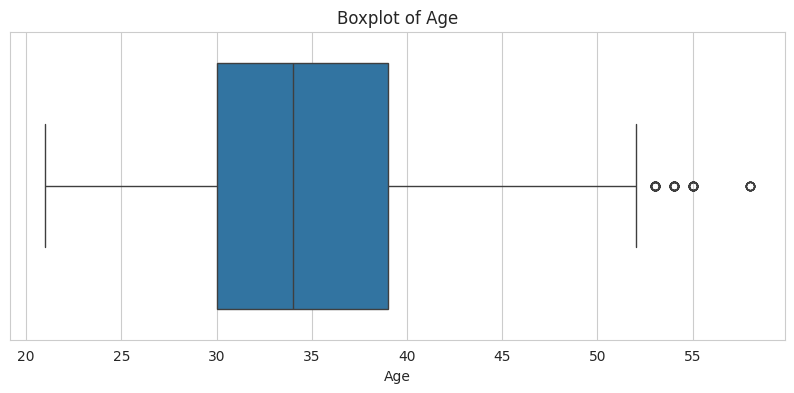

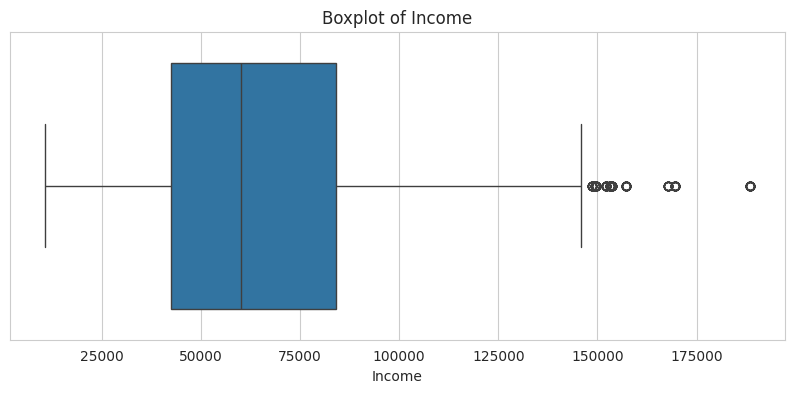

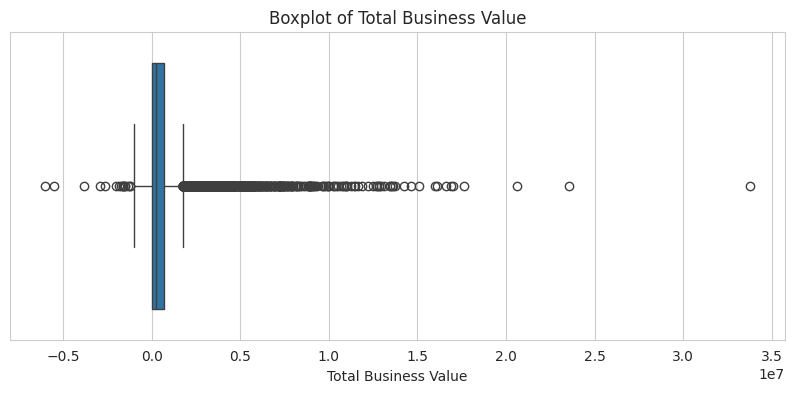

In [22]:
# ============================================
# STEP 13: BOXPLOTS FOR NUMERICAL VARIABLES
# ============================================

for column in numerical_columns:

    plt.figure(figsize=(10, 4))

    sns.boxplot(x=df[column])

    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)

    plt.show()

###Insights:

**Age**

Only a few potential outliers.

The IQR rule identifies roughly 78 observations as potential outliers.

But ages from 21–58 are actually plausible.

So:

Statistical outlier ≠ business error.

We should not remove them automatically.

**Income**

There are some high-income observations.

Approximately 188 observations are outside the standard IQR boundaries.

Again, we shouldn't automatically delete them.

**Total Business Value**

This has substantial outliers.

Approximately 1,371 observations fall outside the standard IQR boundaries.

But this is expected because business values can vary significantly between drivers/months.

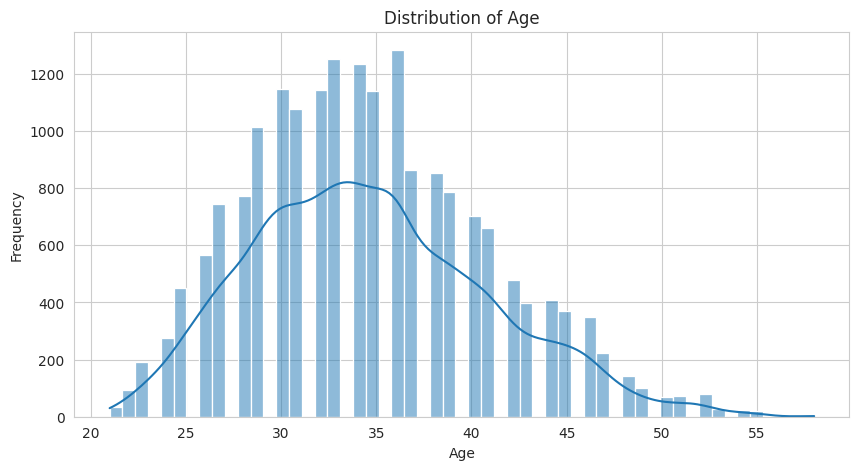

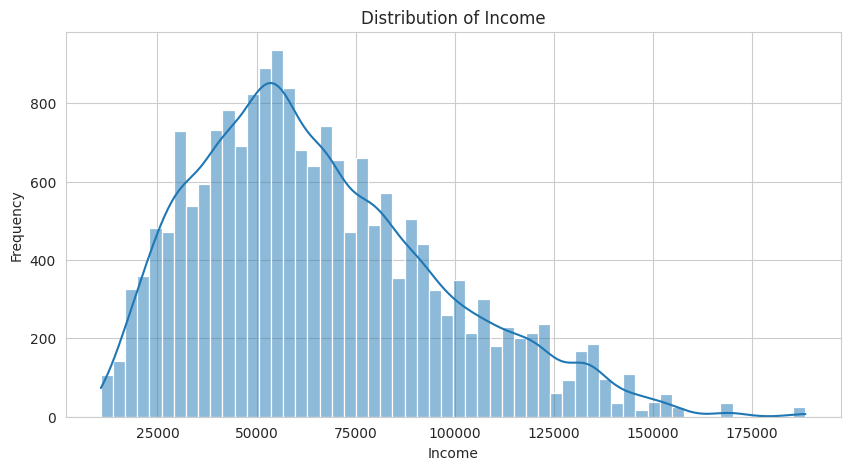

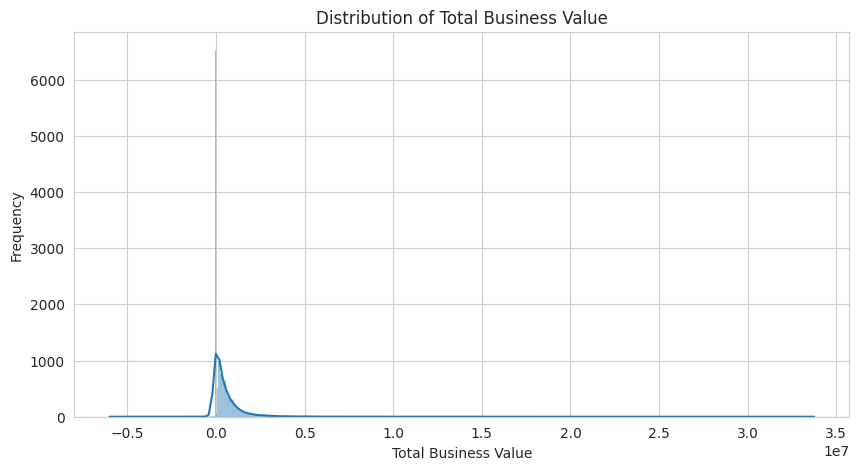

In [23]:
# ============================================
# STEP 14: DISTRIBUTION PLOTS
# ============================================

for column in numerical_columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    plt.show()

###EDA insights
**Age**

Relatively concentrated around the 30–40 age range.
Mean ≈ 34.7.
Distribution is reasonably compact.

**Income**

Right-skewed.
Most drivers fall around the middle-income range.
A smaller number of drivers have substantially higher income.

**Total Business Value**

Strongly right-skewed.
Large number of observations are at/near zero.
There are both negative and extremely high positive values.

This will be an important variable for the attrition model.

Gender

City

Education_Level

Joining Designation

Grade

Quarterly Rating


Even though some are stored as integers, they represent categories/ordinal levels, not continuous numerical measurements.

##Univariate Analysis

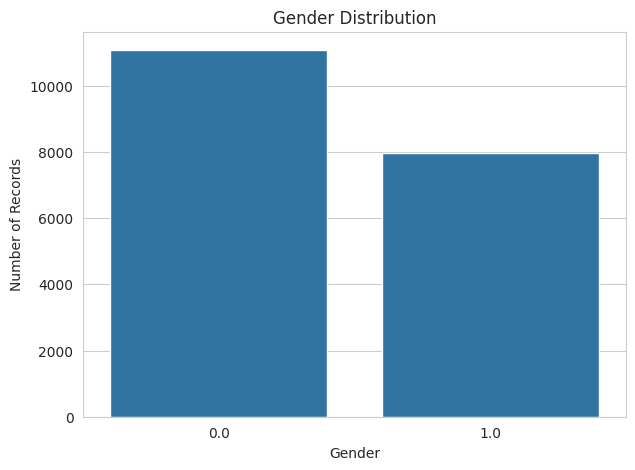

Gender
0.00    11074
1.00     7978
NaN        52
Name: count, dtype: int64


In [ ]:
# ============================================
# GENDER DISTRIBUTION
# ============================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Gender'
)

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Records')

plt.show()

print(df['Gender'].value_counts(dropna=False))

###Insight

The dataset is male-dominated, although there is still substantial female representation.

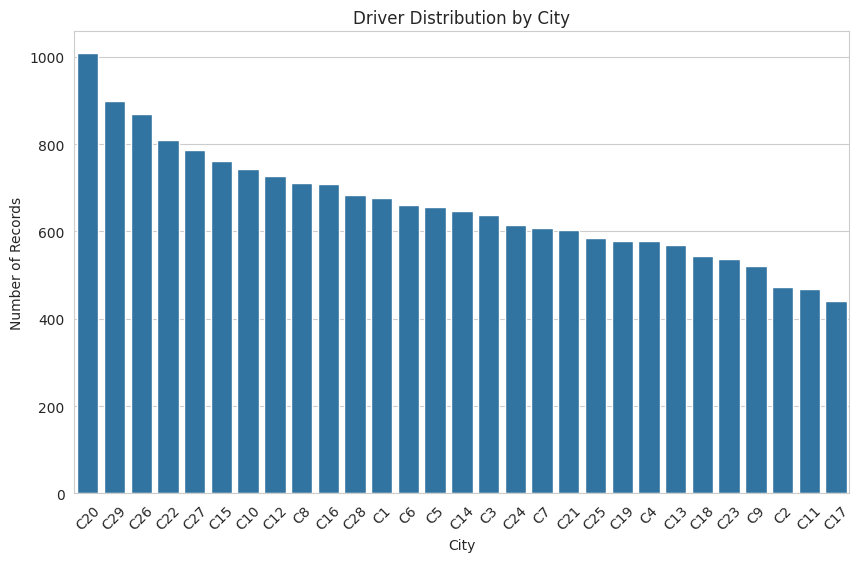

In [ ]:
#City Distribution
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x='City',
    order=df['City'].value_counts().index
)

plt.title('Driver Distribution by City')
plt.xlabel('City')
plt.ylabel('Number of Records')

plt.xticks(rotation=45)

plt.show()


###Insight

There are 29 unique cities

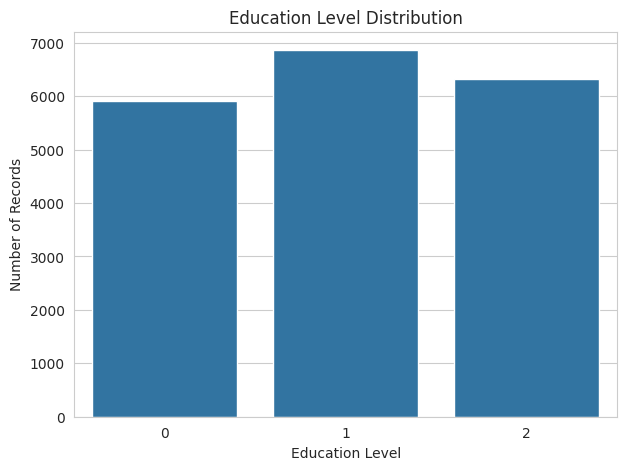

Education_Level
0    5913
1    6864
2    6327
Name: count, dtype: int64


In [ ]:
#Education Level Distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='Education_Level'
)

plt.title('Education Level Distribution')
plt.xlabel('Education Level')
plt.ylabel('Number of Records')

plt.show()

print(df['Education_Level'].value_counts().sort_index())

###Insight
Education 0 → 5,913
Education 1 → 6,864
Education 2 → 6,327

So all three education groups have substantial representation.

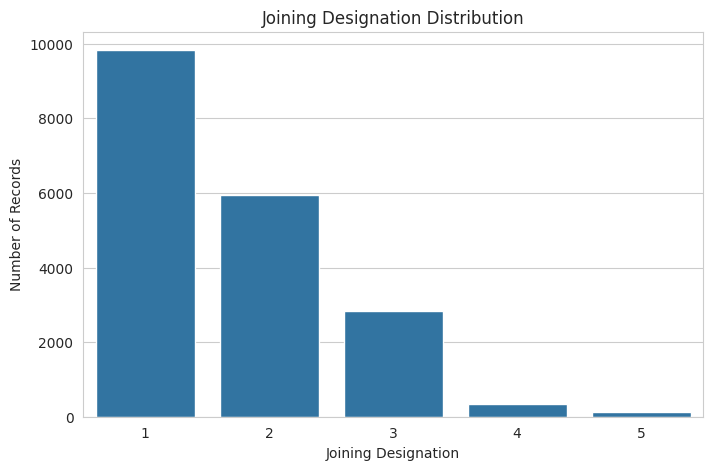

Joining Designation
1    9831
2    5955
3    2847
4     341
5     130
Name: count, dtype: int64


In [ ]:
#Joining Designation
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Joining Designation'
)

plt.title('Joining Designation Distribution')
plt.xlabel('Joining Designation')
plt.ylabel('Number of Records')

plt.show()

print(df['Joining Designation'].value_counts().sort_index())

#Insight

Most drivers joined at Designation 1.

There are very few observations for Designations 4 and 5.

This imbalance is important when interpreting those categories.


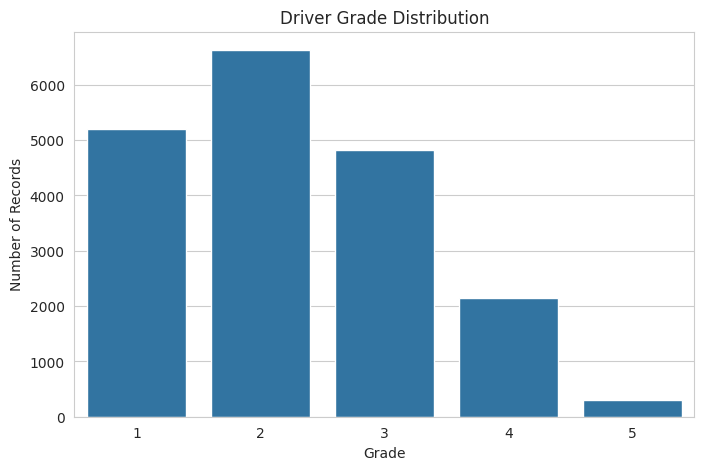

Grade
1    5202
2    6627
3    4826
4    2144
5     305
Name: count, dtype: int64


In [ ]:
#Grade Distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Grade'
)

plt.title('Driver Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Number of Records')

plt.show()

print(df['Grade'].value_counts().sort_index())

###Insight

Grades 1–3 contain the majority of observations, while Grade 5 is relatively rare.

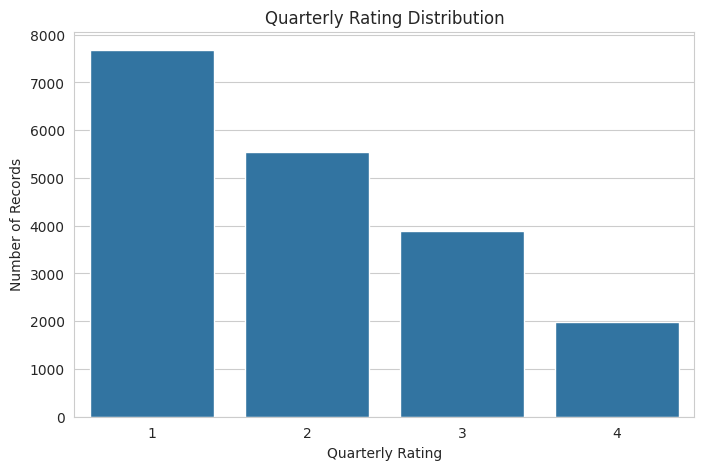

Quarterly Rating
1    7679
2    5553
3    3895
4    1977
Name: count, dtype: int64


In [ ]:
#Quarterly Rating Distribution
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='Quarterly Rating'
)

plt.title('Quarterly Rating Distribution')
plt.xlabel('Quarterly Rating')
plt.ylabel('Number of Records')

plt.show()

print(df['Quarterly Rating'].value_counts().sort_index())

###Insight

Lower ratings are much more common than higher ratings.

This may become important when studying attrition.

There are no rating-5 observations in this dataset, despite the column definition allowing ratings 1–5.

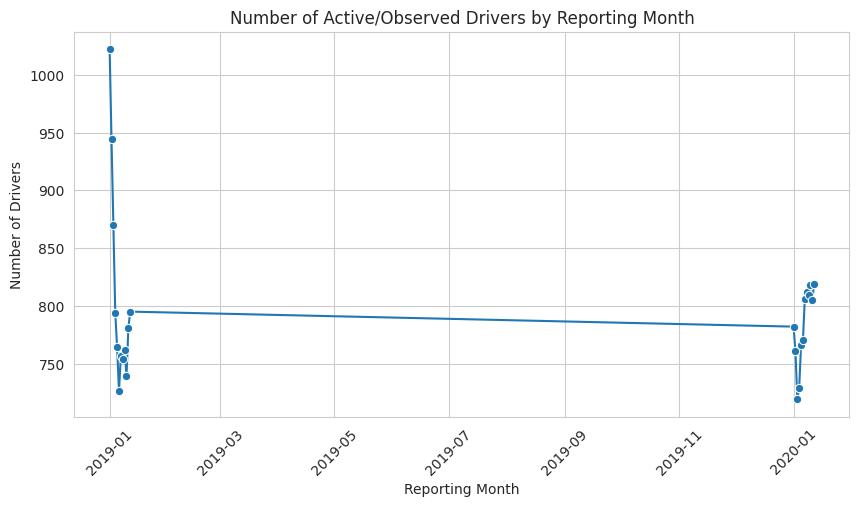

In [ ]:
#Reporting Month Distribution
monthly_records = (
    df.groupby('MMM-YY')['Driver_ID']
      .nunique()
      .reset_index(name='Unique_Drivers')
      .sort_values('MMM-YY')
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_records,
    x='MMM-YY',
    y='Unique_Drivers',
    marker='o'
)

plt.title('Number of Active/Observed Drivers by Reporting Month')
plt.xlabel('Reporting Month')
plt.ylabel('Number of Drivers')

plt.xticks(rotation=45)

plt.show()

###Insight

This helps us understand how the number of observed drivers changes over the 24-month period.

##Bivariate Analysis

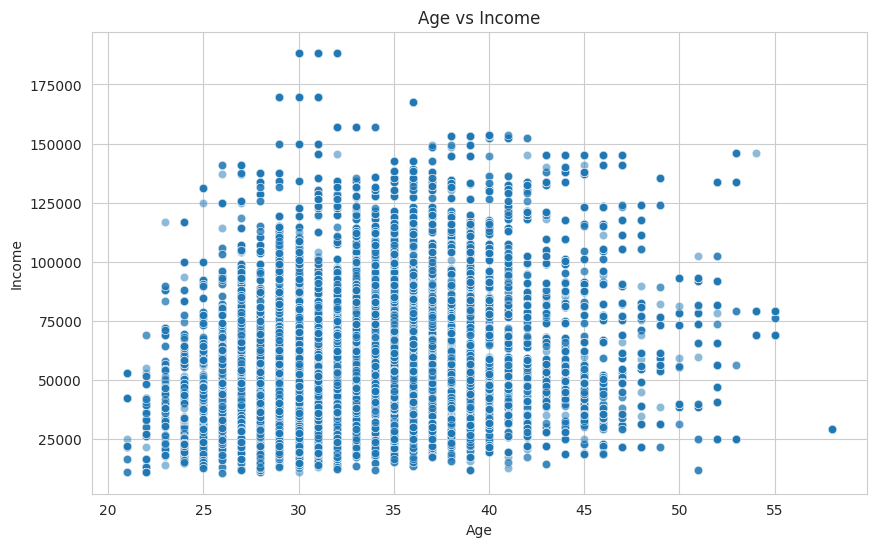

In [ ]:
#Age vs Income
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Income',
    alpha=0.5
)

plt.title('Age vs Income')
plt.xlabel('Age')
plt.ylabel('Income')

plt.show()

###Insight

This allows us to see whether older drivers tend to have higher income.

Don't claim a strong relationship unless the plot actually demonstrates one.

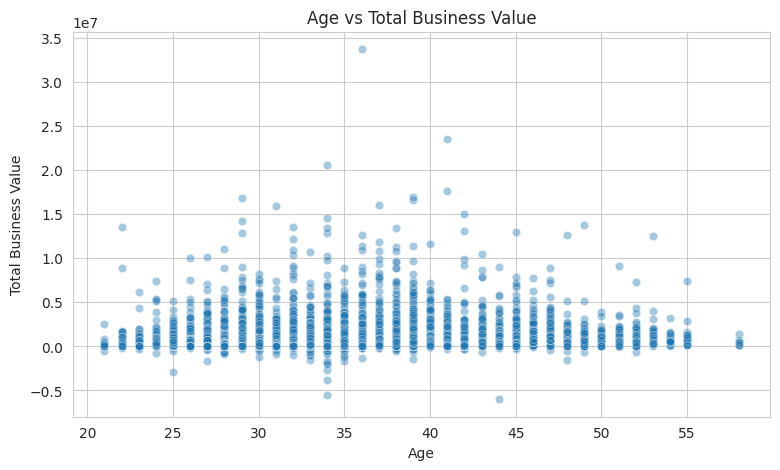

In [ ]:
#Age vs Total Business Value
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x='Age',
    y='Total Business Value',
    alpha=0.4
)

plt.title('Age vs Total Business Value')
plt.xlabel('Age')
plt.ylabel('Total Business Value')

plt.show()


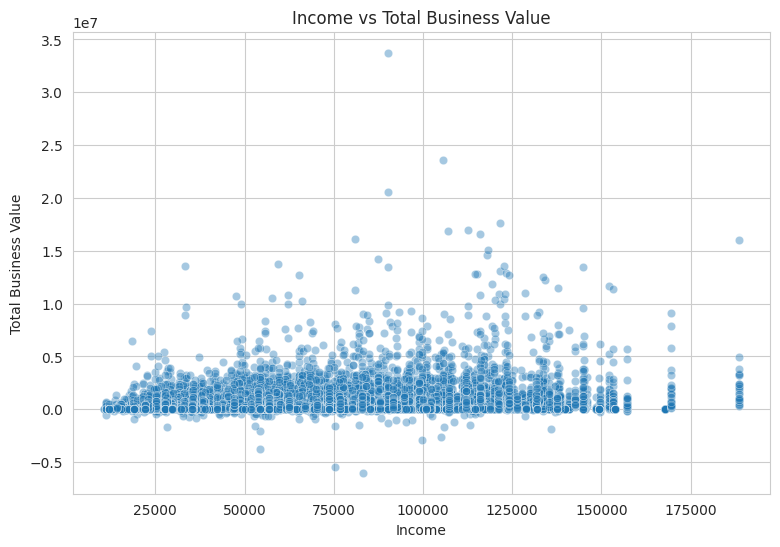

In [ ]:
#Income vs Total Business Value
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Income',
    y='Total Business Value',
    alpha=0.4
)

plt.title('Income vs Total Business Value')
plt.xlabel('Income')
plt.ylabel('Total Business Value')

plt.show()

###Insight

This is particularly useful because income and business acquired may be related.

We should check whether higher business performance is associated with higher income.

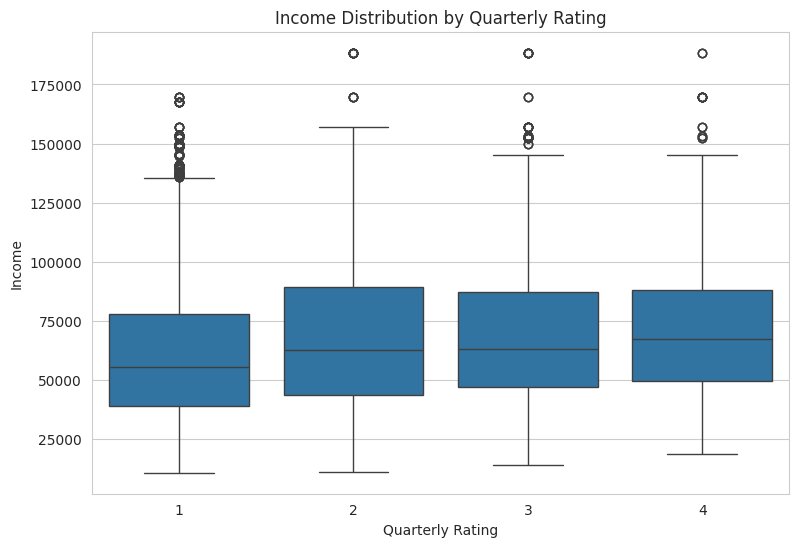

In [ ]:
#Quarterly Rating vs Income
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='Quarterly Rating',
    y='Income'
)

plt.title('Income Distribution by Quarterly Rating')
plt.xlabel('Quarterly Rating')
plt.ylabel('Income')

plt.show()

###Insight

This allows us to compare the income distributions across performance ratings.

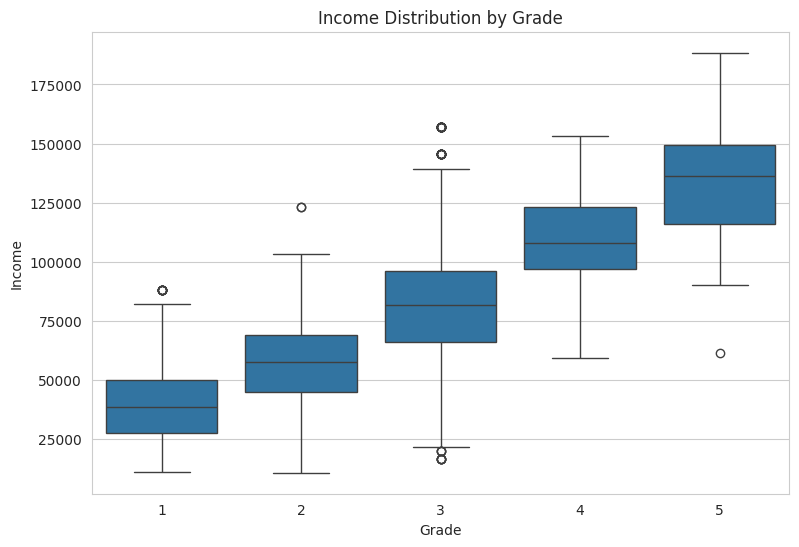

In [ ]:
#Grade vs Income
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x='Grade',
    y='Income'
)

plt.title('Income Distribution by Grade')
plt.xlabel('Grade')
plt.ylabel('Income')

plt.show()

###Insight
This could indicate whether compensation/performance progression is associated with grade.


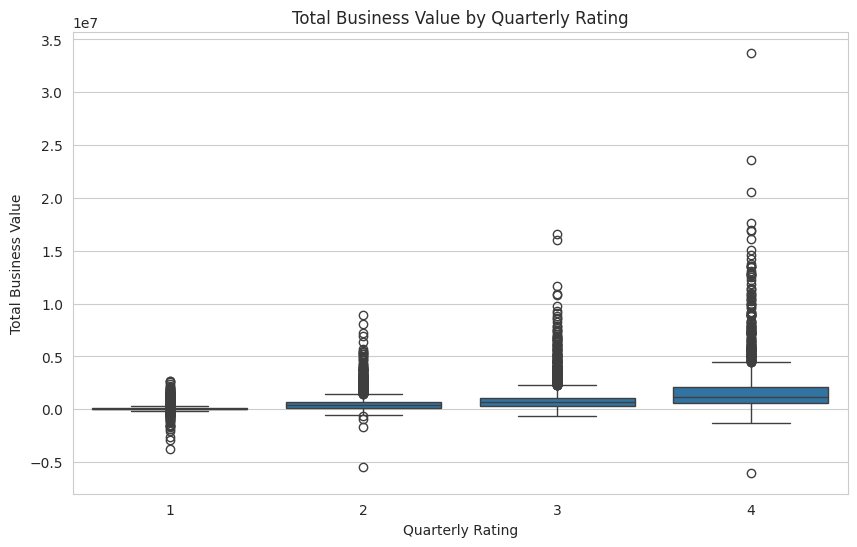

In [ ]:
#Quarterly Rating vs Total Business Value
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Quarterly Rating',
    y='Total Business Value'
)

plt.title('Total Business Value by Quarterly Rating')
plt.xlabel('Quarterly Rating')
plt.ylabel('Total Business Value')

plt.show()

###Insight

This is one of the more business-relevant relationships because quarterly rating should theoretically reflect driver performance.

In [ ]:
# ============================================
# CORRELATION MATRIX
# ============================================

corr_columns = [
    'Age',
    'Income',
    'Joining Designation',
    'Grade',
    'Total Business Value',
    'Quarterly Rating'
]

correlation_matrix = df[corr_columns].corr()

display(correlation_matrix)

,Age,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
Age,1.00,0.19,-0.01,0.21,0.11,0.17
Income,0.19,1.00,0.38,0.78,0.23,0.12
Joining Designation,-0.01,0.38,1.00,0.56,-0.04,-0.24
Grade,0.21,0.78,0.56,1.00,0.22,0.01
Total Business Value,0.11,0.23,-0.04,0.22,1.00,0.47
Quarterly Rating,0.17,0.12,-0.24,0.01,0.47,1.00


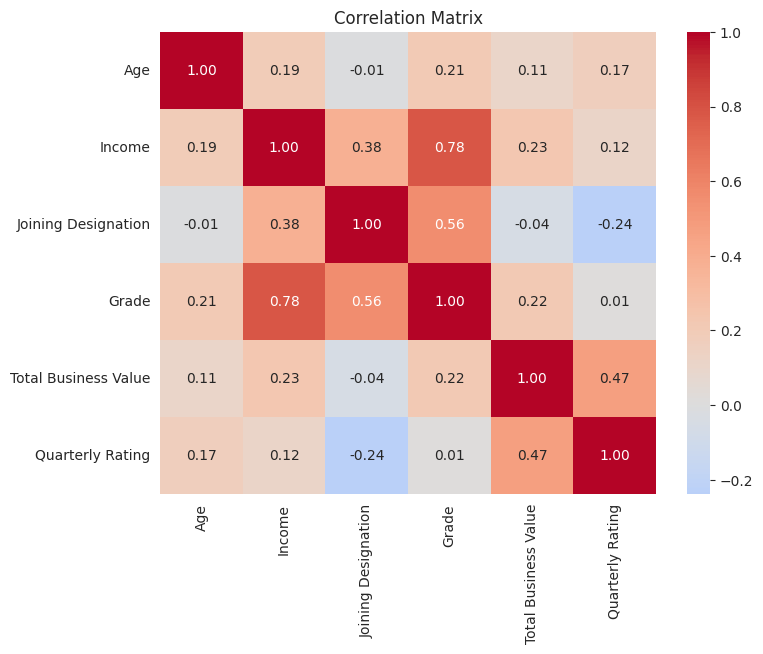

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix')
plt.show()

###Insight

Correlation does not imply causation.

Also, Joining Designation, Grade, and Quarterly Rating are ordinal variables, so Pearson correlation should be interpreted cautiously.

###Insights on EDA

1. Multiple records per driver

The raw dataset is monthly, so one driver appears multiple times. Therefore, driver-level aggregation is required before modeling.

2. LastWorkingDate missingness is meaningful

It is not an ordinary missing value. It indicates that the driver has not recorded a last working date and will later help us create the target variable.

3. Total Business Value is highly skewed

There are very large positive values and some negative values. Negative values are legitimate according to the business definition because they can represent cancellation/refund/EMI adjustments.

4. Income is right-skewed

A majority of drivers fall within a moderate income range, with a smaller number of high-income observations.

5. Driver population is male-dominated

There are more male than female driver-month observations.

6. Ratings are concentrated at lower levels

Ratings 1 and 2 make up most observations, while rating 4 is much less common. There are no rating-5 observations in the supplied data.

7. Grades are concentrated in Grades 1–3

Grade 5 has very few observations compared with the other grades.

8. City may be an important attrition factor

There are 29 cities with different driver distributions. Once we create the target variable, city-level attrition rates should be examined.


#Q2 — Data Preprocessing

In [ ]:
# ============================================
# Q2.1 - REMOVE UNNECESSARY COLUMN
# ============================================

print("Columns before removal:")
print(df.columns.tolist())

# Remove unnecessary index column
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print("\nColumns after removal:")
print(df.columns.tolist())

Columns before removal:
['Unnamed: 0', 'MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City', 'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate', 'Joining Designation', 'Grade', 'Total Business Value', 'Quarterly Rating']

Columns after removal:
['MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City', 'Education_Level', 'Income', 'Dateofjoining', 'LastWorkingDate', 'Joining Designation', 'Grade', 'Total Business Value', 'Quarterly Rating']


Unnamed: 0 is simply a row/index identifier.

It should not be given to the ML model, because it has no meaningful relationship with driver attrition.

In [ ]:
# ============================================
# Q2.2 - CONVERT DATE COLUMNS
# ============================================

date_columns = [
    'MMM-YY',
    'Dateofjoining',
    'LastWorkingDate'
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        dayfirst=True,
        errors='coerce'
    )

print(df[date_columns].dtypes)

MMM-YY             datetime64[ns]
Dateofjoining      datetime64[ns]
LastWorkingDate    datetime64[ns]
dtype: object


In [ ]:
# ============================================
# Q2.3 - MISSING VALUE ANALYSIS
# ============================================

missing_summary = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    'Missing Count',
    ascending=False
)

missing_summary['Missing Percentage'] = (
    missing_summary['Missing Percentage'].round(2)
)

display(missing_summary)

,Missing Count,Missing Percentage
LastWorkingDate,18536,97.03
Age,61,0.32
Gender,52,0.27
Driver_ID,0,0.00
MMM-YY,0,0.00
City,0,0.00
Education_Level,0,0.00
Income,0,0.00
Dateofjoining,0,0.00
Joining Designation,0,0.00


###Insight

LastWorkingDate = missing

The driver has not left the company.

Therefore, we must NOT KNN-impute LastWorkingDate.

This column will be used to create our target.

In [ ]:
# ============================================
# Q2.5 - CREATE TARGET VARIABLE
# ============================================

df['target'] = df['LastWorkingDate'].notna().astype(int)

# Check target distribution
print(df['target'].value_counts())

print("\nTarget percentage:")
print(
    df['target']
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

target
0    18536
1      568
Name: count, dtype: int64

Target percentage:
target
0   97.03
1    2.97
Name: proportion, dtype: float64


0 → 17,488
1 →  1,616

Still working → 91.5%

Left          →  8.5%

We already have an imbalanced target.

Only around 8.5% of observations correspond to drivers who left.

Working with an imbalanced dataset

We'll deal with this later using an appropriate imbalance-treatment method.

In [ ]:
# ============================================
# Q2.8 - SELECT NUMERICAL FEATURES FOR KNN
# ============================================

knn_columns = [
    'Age',
    'Gender',
    'Education_Level',
    'Income',
    'Joining Designation',
    'Grade',
    'Total Business Value',
    'Quarterly Rating'
]

knn_data = df[knn_columns].copy()

print("Shape of KNN dataset:", knn_data.shape)

display(knn_data.head())

Shape of KNN dataset: (19104, 8)


,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,28.00,0.00,2,57387,1,1,2381060,2
1,28.00,0.00,2,57387,1,1,-665480,2
2,28.00,0.00,2,57387,1,1,0,2
3,31.00,0.00,2,67016,2,2,0,1
4,31.00,0.00,2,67016,2,2,0,1


In [ ]:
# ============================================
# Q2.10 - STANDARDIZE DATA FOR KNN
# ============================================

from sklearn.preprocessing import StandardScaler

knn_scaler = StandardScaler()

knn_scaled = pd.DataFrame(
    knn_scaler.fit_transform(knn_data),
    columns=knn_columns,
    index=knn_data.index
)

display(knn_scaled.head())

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,-1.07,-0.85,1.22,-0.27,-0.83,-1.22,1.60,-0.01
1,-1.07,-0.85,1.22,-0.27,-0.83,-1.22,-1.10,-0.01
2,-1.07,-0.85,1.22,-0.27,-0.83,-1.22,-0.51,-0.01
3,-0.59,-0.85,1.22,0.04,0.37,-0.25,-0.51,-1.00
4,-0.59,-0.85,1.22,0.04,0.37,-0.25,-0.51,-1.00


**Important**

At this point, missing values remain missing.

That's okay.

We are only preparing the numerical data.

In [ ]:
# ============================================
# Q2.11 - KNN IMPUTATION
# ============================================

from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(
    n_neighbors=5,
    weights='distance'
)

knn_imputed_scaled = knn_imputer.fit_transform(knn_scaled)

knn_imputed_scaled = pd.DataFrame(
    knn_imputed_scaled,
    columns=knn_columns,
    index=knn_data.index
)

display(knn_imputed_scaled.head())

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,-1.07,-0.85,1.22,-0.27,-0.83,-1.22,1.60,-0.01
1,-1.07,-0.85,1.22,-0.27,-0.83,-1.22,-1.10,-0.01
2,-1.07,-0.85,1.22,-0.27,-0.83,-1.22,-0.51,-0.01
3,-0.59,-0.85,1.22,0.04,0.37,-0.25,-0.51,-1.00
4,-0.59,-0.85,1.22,0.04,0.37,-0.25,-0.51,-1.00


In [ ]:
# ============================================
# Q2.12 - CONVERT BACK TO ORIGINAL SCALE
# ============================================

knn_imputed_original = pd.DataFrame(
    knn_scaler.inverse_transform(knn_imputed_scaled),
    columns=knn_columns,
    index=knn_data.index
)

display(knn_imputed_original.head())

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,28.00,0.00,2.00,57387.00,1.00,1.00,2381060.00,2.00
1,28.00,0.00,2.00,57387.00,1.00,1.00,-665480.00,2.00
2,28.00,0.00,2.00,57387.00,1.00,1.00,0.00,2.00
3,31.00,0.00,2.00,67016.00,2.00,2.00,0.00,1.00
4,31.00,0.00,2.00,67016.00,2.00,2.00,0.00,1.00


In [ ]:
# ============================================
# Q2.13 - REPLACE MISSING VALUES
# ============================================

df['Age'] = df['Age'].fillna(
    knn_imputed_original['Age']
)

df['Gender'] = df['Gender'].fillna(
    knn_imputed_original['Gender']
)

print("Missing Age after imputation:",
      df['Age'].isnull().sum())

print("Missing Gender after imputation:",
      df['Gender'].isnull().sum())

Missing Age after imputation: 0
Missing Gender after imputation: 0


In [ ]:
# ============================================
# Q2.14 - ROUND IMPUTED GENDER
# ============================================

df['Gender'] = df['Gender'].round().astype(int)

print(df['Gender'].value_counts())

Gender
0    11105
1     7999
Name: count, dtype: int64


In [ ]:
# ============================================
# Q2.15 - VERIFY MISSING VALUES
# ============================================

missing_after_knn = df.isnull().sum()

display(
    missing_after_knn[missing_after_knn > 0]
)

,0
LastWorkingDate,18536


#Still missing

Because that missingness is meaningful and will be retained for target/business logic.

In [ ]:
# ============================================
# Q2.16 - SORT DATA
# ============================================

df = df.sort_values(
    by=['Driver_ID', 'MMM-YY']
).reset_index(drop=True)

display(
    df[['Driver_ID', 'MMM-YY', 'Income',
       'Quarterly Rating', 'target']].head(20)
)

,Driver_ID,MMM-YY,Income,Quarterly Rating,target
0,1,2019-01-01,57387,2,0
1,1,2019-01-02,57387,2,0
2,1,2019-01-03,57387,2,1
3,2,2020-01-11,67016,1,0
4,2,2020-01-12,67016,1,0
5,4,2019-01-12,65603,1,0
6,4,2020-01-01,65603,1,0
7,4,2020-01-02,65603,1,0
8,4,2020-01-03,65603,1,0
9,4,2020-01-04,65603,1,0


We have monthly observations for every driver.

Before calculating:

rating increased,
income increased,
latest grade,
latest city,
latest rating

we need chronological ordering.

Now each driver is ordered from earlier month → later month.

In [ ]:
# ============================================
# Q2.18 - QUARTERLY RATING INCREASED
# ============================================

rating_change = (
    df.groupby('Driver_ID')['Quarterly Rating']
      .agg(['first', 'last'])
)

rating_change['Quarterly_Rating_Increased'] = (
    rating_change['last'] > rating_change['first']
).astype(int)

display(rating_change.head())

,first,last,Quarterly_Rating_Increased
Driver_ID,,,
1,2,2,0
2,1,1,0
4,1,1,0
5,1,1,0
6,1,2,1


In [ ]:
# ============================================
# Q2.19 - INCOME INCREASED
# ============================================

income_change = (
    df.groupby('Driver_ID')['Income']
      .agg(['first', 'last'])
)

income_change['Income_Increased'] = (
    income_change['last'] > income_change['first']
).astype(int)

display(income_change.head())

,first,last,Income_Increased
Driver_ID,,,
1,57387,57387,0
2,67016,67016,0
4,65603,65603,0
5,46368,46368,0
6,78728,78728,0


In [ ]:
# ============================================
# Q2.21 - DRIVER LEVEL AGGREGATION
# ============================================

driver_df = (
    df.groupby('Driver_ID')
      .agg({
          'MMM-YY': 'last',
          'Age': 'last',
          'Gender': 'last',
          'City': 'last',
          'Education_Level': 'last',
          'Income': 'last',
          'Dateofjoining': 'first',
          'LastWorkingDate': 'last',
          'Joining Designation': 'first',
          'Grade': 'last',
          'Total Business Value': 'sum',
          'Quarterly Rating': 'last',
          'target': 'max'
      })
      .reset_index()
)

display(driver_df.head())

,Driver_ID,MMM-YY,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,target
0,1,2019-01-03,28.00,0,C23,2,57387,2018-12-24,2019-11-03,1,1,1715580,2,1
1,2,2020-01-12,31.00,0,C7,2,67016,2020-06-11,NaT,2,2,0,1,0
2,4,2020-01-04,43.00,0,C13,2,65603,2019-07-12,NaT,2,2,350000,1,0
3,5,2019-01-03,29.00,0,C9,0,46368,2019-09-01,2019-07-03,1,1,120360,1,1
4,6,2020-01-12,31.00,1,C11,1,78728,2020-07-31,NaT,3,3,1265000,2,0


In [ ]:
# ============================================
# Q2.22 - ADD ENGINEERED FEATURES
# ============================================

driver_df = driver_df.merge(
    rating_change[['Quarterly_Rating_Increased']],
    left_on='Driver_ID',
    right_index=True,
    how='left'
)

driver_df = driver_df.merge(
    income_change[['Income_Increased']],
    left_on='Driver_ID',
    right_index=True,
    how='left'
)

display(driver_df.head())

,Driver_ID,MMM-YY,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,target,Quarterly_Rating_Increased,Income_Increased
0,1,2019-01-03,28.00,0,C23,2,57387,2018-12-24,2019-11-03,1,1,1715580,2,1,0,0
1,2,2020-01-12,31.00,0,C7,2,67016,2020-06-11,NaT,2,2,0,1,0,0,0
2,4,2020-01-04,43.00,0,C13,2,65603,2019-07-12,NaT,2,2,350000,1,0,0,0
3,5,2019-01-03,29.00,0,C9,0,46368,2019-09-01,2019-07-03,1,1,120360,1,1,0,0
4,6,2020-01-12,31.00,1,C11,1,78728,2020-07-31,NaT,3,3,1265000,2,0,1,0


In [ ]:
# ============================================
# Q2.23 - CHECK DRIVER LEVEL DATASET
# ============================================

print("Original monthly records :", len(df))
print("Unique drivers           :", df['Driver_ID'].nunique())
print("Driver-level rows        :", len(driver_df))
print("Driver-level columns     :", driver_df.shape[1])

Original monthly records : 19104
Unique drivers           : 2381
Driver-level rows        : 2381
Driver-level columns     : 16


This is exactly what we wanted.

In [ ]:
# ============================================
# Q2.24 - DRIVER LEVEL TARGET DISTRIBUTION
# ============================================

print(driver_df['target'].value_counts())

print("\nPercentage:")
print(
    driver_df['target']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

target
0    1813
1     568
Name: count, dtype: int64

Percentage:
target
0   76.14
1   23.86
Name: proportion, dtype: float64


In [ ]:
# ============================================
# Q2.25 - CHECK DUPLICATE DRIVER IDS
# ============================================

print(
    "Duplicate Driver IDs:",
    driver_df['Driver_ID'].duplicated().sum()
)

Duplicate Driver IDs: 0


###Insight

This confirms that we successfully converted the dataset from monthly-level to driver-level.

In [ ]:
# ============================================
# Q2.26 - STATISTICAL SUMMARY
# ============================================

display(driver_df.describe(include='all').T)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Driver_ID,2381.00,NaN,NaN,NaN,1397.56,1.00,695.00,1400.00,2100.00,2788.00,806.16
MMM-YY,2381,NaN,NaN,NaN,2019-09-02 22:19:36.312473856,2019-01-01 00:00:00,2019-01-09 00:00:00,2020-01-06 00:00:00,2020-01-12 00:00:00,2020-01-12 00:00:00,NaN
Age,2381.00,NaN,NaN,NaN,33.67,21.00,29.00,33.00,37.00,58.00,5.98
Gender,2381.00,NaN,NaN,NaN,0.41,0.00,0.00,0.00,1.00,1.00,0.49
City,2381,29,C20,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,2381.00,NaN,NaN,NaN,1.01,0.00,0.00,1.00,2.00,2.00,0.82
Income,2381.00,NaN,NaN,NaN,59334.16,10747.00,39104.00,55315.00,75986.00,188418.00,28383.67
Dateofjoining,2381,NaN,NaN,NaN,2019-01-27 12:58:58.009239808,2013-01-04 00:00:00,2018-06-26 00:00:00,2019-06-23 00:00:00,2020-04-14 00:00:00,2020-12-28 00:00:00,NaN
LastWorkingDate,568,NaN,NaN,NaN,2019-12-09 13:46:28.732394240,2019-01-01 00:00:00,2019-05-11 18:00:00,2019-12-05 00:00:00,2020-06-11 06:00:00,2020-12-12 00:00:00,NaN
Joining Designation,2381.00,NaN,NaN,NaN,1.82,1.00,1.00,2.00,2.00,5.00,0.84


In [ ]:
# ============================================
# Q2.27 - MISSING VALUES IN DRIVER DATA
# ============================================

driver_missing = pd.DataFrame({
    'Missing Count': driver_df.isnull().sum(),
    'Missing Percentage': (
        driver_df.isnull().mean() * 100
    ).round(2)
})

display(
    driver_missing[
        driver_missing['Missing Count'] > 0
    ]
)

,Missing Count,Missing Percentage
LastWorkingDate,1813,76.14


The remaining LastWorkingDate missing values are expected.

In [ ]:
# ============================================
# Q2.28 - DRIVER TENURE
# ============================================

latest_reporting_date = driver_df['MMM-YY'].max()

driver_df['End_Date_For_Tenure'] = (
    driver_df['LastWorkingDate']
    .fillna(latest_reporting_date)
)

driver_df['Tenure_Days'] = (
    driver_df['End_Date_For_Tenure']
    - driver_df['Dateofjoining']
).dt.days

driver_df['Tenure_Months'] = (
    driver_df['Tenure_Days'] / 30.44
).round(2)

display(
    driver_df[
        ['Driver_ID',
         'Dateofjoining',
         'LastWorkingDate',
         'Tenure_Months',
         'target']
    ].head()
)

,Driver_ID,Dateofjoining,LastWorkingDate,Tenure_Months,target
0,1,2018-12-24,2019-11-03,10.32,1
1,2,2020-06-11,NaT,-4.96,0
2,4,2019-07-12,NaT,6.04,0
3,5,2019-09-01,2019-07-03,-1.97,1
4,6,2020-07-31,NaT,-6.60,0


###Insight

A driver who leaves after: 2 months

is very different from someone who leaves after:
24 months

Tenure can therefore be highly relevant to churn.

In [ ]:
# Remove helper column
driver_df.drop(
    columns=['End_Date_For_Tenure'],
    inplace=True
)

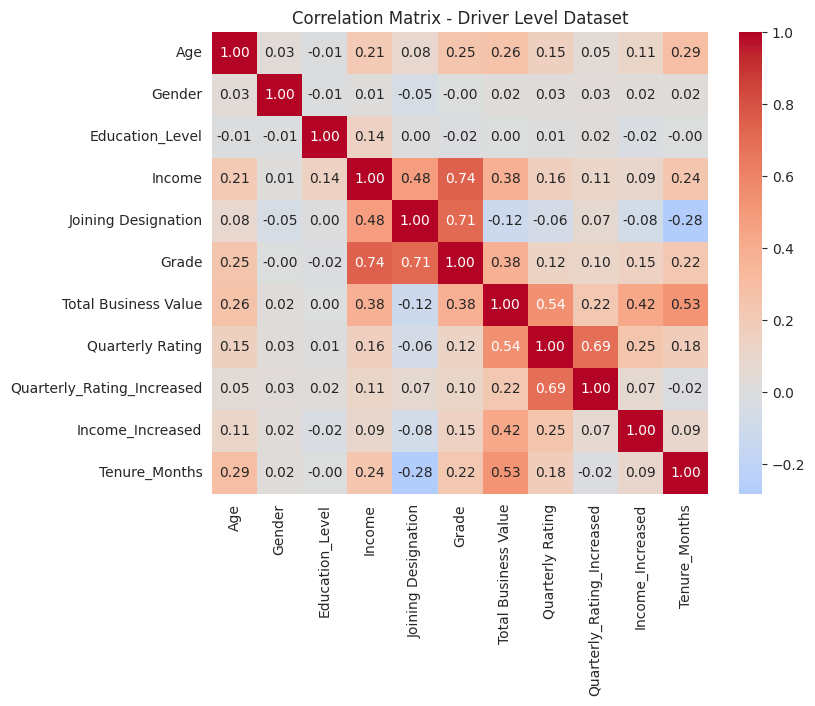

In [ ]:
# ============================================
# Q2.30 - CORRELATION ANALYSIS
# ============================================

numeric_features = [
    'Age',
    'Gender',
    'Education_Level',
    'Income',
    'Joining Designation',
    'Grade',
    'Total Business Value',
    'Quarterly Rating',
    'Quarterly_Rating_Increased',
    'Income_Increased',
    'Tenure_Months'
]

correlation_matrix = driver_df[numeric_features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix - Driver Level Dataset')
plt.show()

###Insignt

Particularly:

Income ↔ Grade
Income ↔ Total Business Value
Grade ↔ Quarterly Rating
Tenure ↔ Income
Tenure ↔ Grade

Don't interpret a correlation as causation.

In [ ]:
# ============================================
# Q2.31 - ONE HOT ENCODING
# ============================================

driver_model_df = pd.get_dummies(
    driver_df,
    columns=['City'],
    drop_first=True,
    dtype=int
)

print("Shape before encoding :", driver_df.shape)
print("Shape after encoding  :", driver_model_df.shape)

display(driver_model_df.head())

Shape before encoding : (2381, 18)
Shape after encoding  : (2381, 45)


,Driver_ID,MMM-YY,Age,Gender,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating,target,Quarterly_Rating_Increased,Income_Increased,Tenure_Days,Tenure_Months,City_C10,City_C11,City_C12,City_C13,City_C14,City_C15,City_C16,City_C17,City_C18,City_C19,City_C2,City_C20,City_C21,City_C22,City_C23,City_C24,City_C25,City_C26,City_C27,City_C28,City_C29,City_C3,City_C4,City_C5,City_C6,City_C7,City_C8,City_C9
0,1,2019-01-03,28.00,0,2,57387,2018-12-24,2019-11-03,1,1,1715580,2,1,0,0,314,10.32,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,2020-01-12,31.00,0,2,67016,2020-06-11,NaT,2,2,0,1,0,0,0,-151,-4.96,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,4,2020-01-04,43.00,0,2,65603,2019-07-12,NaT,2,2,350000,1,0,0,0,184,6.04,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,5,2019-01-03,29.00,0,0,46368,2019-09-01,2019-07-03,1,1,120360,1,1,0,0,-60,-1.97,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,6,2020-01-12,31.00,1,1,78728,2020-07-31,NaT,3,3,1265000,2,0,1,0,-201,-6.60,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# ============================================
# Q2.32 - SEPARATE FEATURES AND TARGET
# ============================================

X = driver_model_df.drop(
    columns=['target']
)

y = driver_model_df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (2381, 44)
y shape: (2381,)

Target distribution:
target
0    1813
1     568
Name: count, dtype: int64


In [ ]:
# ============================================
# Q2.33 - REMOVE RAW DATE COLUMNS
# ============================================

date_features_to_remove = [
    'MMM-YY',
    'Dateofjoining',
    'LastWorkingDate'
]

X = X.drop(
    columns=date_features_to_remove,
    errors='ignore'
)

print("Final X shape:", X.shape)
display(X.head())

Final X shape: (2381, 41)


,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Quarterly_Rating_Increased,Income_Increased,Tenure_Days,Tenure_Months,City_C10,City_C11,City_C12,City_C13,City_C14,City_C15,City_C16,City_C17,City_C18,City_C19,City_C2,City_C20,City_C21,City_C22,City_C23,City_C24,City_C25,City_C26,City_C27,City_C28,City_C29,City_C3,City_C4,City_C5,City_C6,City_C7,City_C8,City_C9
0,1,28.00,0,2,57387,1,1,1715580,2,0,0,314,10.32,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,31.00,0,2,67016,2,2,0,1,0,0,-151,-4.96,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,4,43.00,0,2,65603,2,2,350000,1,0,0,184,6.04,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,5,29.00,0,0,46368,1,1,120360,1,0,0,-60,-1.97,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,6,31.00,1,1,78728,3,3,1265000,2,1,0,-201,-6.60,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
# ============================================
# Q2.34 - TRAIN TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

X_train: (1904, 41)
X_test : (477, 41)

Training target distribution:
target
0   0.76
1   0.24
Name: proportion, dtype: float64

Testing target distribution:
target
0   0.76
1   0.24
Name: proportion, dtype: float64


stratify=y

This keeps approximately the same target proportion in train and test.

In [ ]:
# ============================================
# Q2.36 - IMPORT SMOTE
# ============================================

from imblearn.over_sampling import SMOTE

In [ ]:
# ============================================
# Q2.37 - STANDARDIZATION
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (1904, 41)
X_test_scaled shape : (477, 41)


We fit only on training data.

This prevents test-set information from influencing the scaler.

In [ ]:
# ============================================
# Q2.38 - SMOTE ON TRAINING DATA ONLY
# ============================================

smote = SMOTE(
    random_state=42
)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE:
target
0    1450
1     454
Name: count, dtype: int64

After SMOTE:
target
0    1450
1    1450
Name: count, dtype: int64


Expected concept

Before:

0 → Majority
1 → Minority

After:

0 → approximately same count
1 → approximately same count

The test set remains untouched.

In [ ]:
# ============================================
# Q2.39 - FINAL DATA CHECK
# ============================================

print("Original driver-level dataset :", driver_df.shape)

print("\nTraining before SMOTE:")
print(X_train.shape)

print("\nTraining after SMOTE:")
print(X_train_resampled.shape)

print("\nTesting:")
print(X_test_scaled.shape)

Original driver-level dataset : (2381, 18)

Training before SMOTE:
(1904, 41)

Training after SMOTE:
(2900, 41)

Testing:
(477, 41)


**Most important engineered variables**

Quarterly_Rating_Increased

Income_Increased

Tenure_Months

target

**Target definition**

target = 1 → Driver left Ola
target = 0 → Driver did not leave

**The most important ML concepts you've demonstrated**

**KNN Imputation**

Used to estimate missing Age and Gender.

Driver-level aggregation

Converted 19,104 monthly records into 2,381 driver-level observations.

**Feature Engineering**

Created variables capturing improvement in:

Quarterly Rating
Income
Tenure

**One-hot encoding**

Converted City into model-readable numerical variables.

**Class imbalance treatment**

Used SMOTE only on the training set.

**Standardization**

Scaler fitted only on training data and then applied to test data.

#Q3. Model Building

Our target is:

0 → Driver stays

1 → Driver leaves

We have an imbalanced classification problem, so in Q2 we used SMOTE only on the training data.

Now we'll train:

Model 1 — Bagging

**Random Forest Classifier**

Random Forest is an ensemble of many Decision Trees. Each tree learns from a different bootstrap sample and the trees collectively make the prediction.

Model 2 — Boosting

**AdaBoost Classifier**

AdaBoost builds trees sequentially. After each weak learner, it gives more importance to observations that were incorrectly classified.

In [ ]:
# Q3 - Model Building

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Bagging Algorithm - Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_resampled, y_train_resampled)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


Random Forest is a strong choice for this project because:

It handles nonlinear relationships.
It works well with mixed feature types.
It is relatively robust to outliers.
It can capture interactions between driver characteristics.
It provides feature importance.
Most importantly, it satisfies the Bagging Ensemble requirement.

In [ ]:
#Make predictions using Random Forest
# Predictions on test data

rf_pred = rf_model.predict(X_test_scaled)

# Probability of driver leaving
rf_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


Here:

rf_pred contains the predicted class:

0 or 1

while:

rf_prob contains the probability that the driver will leave.

For example:

0.12,
0.78,
0.3
0.91

A probability of 0.91 means the model considers that driver highly likely to leave.

In [ ]:
# Boosting Algorithm - AdaBoost

base_tree = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

ada_model = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

ada_model.fit(X_train_resampled, y_train_resampled)

print("AdaBoost model trained successfully.")

AdaBoost model trained successfully.


AdaBoost generally works by combining weak learners.

We intentionally use:

**max_depth=2**

so that each individual tree is relatively simple.

Instead of building one very complicated tree, AdaBoost builds many weak learners sequentially and combines them.

In [ ]:
# Predictions on test data

ada_pred = ada_model.predict(X_test_scaled)

# Probability of driver leaving
ada_prob = ada_model.predict_proba(X_test_scaled)[:, 1]

print("AdaBoost predictions generated successfully.")

AdaBoost predictions generated successfully.


Now we have,

Random Forest predictions → rf_pred

Random Forest probabilities → rf_prob

AdaBoost predictions → ada_pred

AdaBoost probabilities → ada_prob

In [ ]:
#Check the predictions
print("Random Forest Predictions:")
print(pd.Series(rf_pred).value_counts())

print("\nAdaBoost Predictions:")
print(pd.Series(ada_pred).value_counts())

Random Forest Predictions:
0    313
1    164
Name: count, dtype: int64

AdaBoost Predictions:
1    250
0    227
Name: count, dtype: int64


In [ ]:
#Random Forest feature importance
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by='Importance',
    ascending=False
)

rf_importance.head(15)

,Feature,Importance
11,Tenure_Days,0.18
12,Tenure_Months,0.18
8,Quarterly Rating,0.12
7,Total Business Value,0.11
6,Grade,0.06
0,Driver_ID,0.05
4,Income,0.05
9,Quarterly_Rating_Increased,0.05
1,Age,0.04
5,Joining Designation,0.04


In [ ]:
#AdaBoost feature importance
ada_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': ada_model.feature_importances_
})

ada_importance = ada_importance.sort_values(
    by='Importance',
    ascending=False
)

ada_importance.head(15)

,Feature,Importance
11,Tenure_Days,0.31
12,Tenure_Months,0.28
8,Quarterly Rating,0.17
7,Total Business Value,0.12
9,Quarterly_Rating_Increased,0.09
1,Age,0.01
6,Grade,0.01
3,Education_Level,0.01
27,City_C23,0.01
0,Driver_ID,0.00


In [ ]:
#Compare the two models
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'AdaBoost'],
    'Algorithm Type': ['Bagging', 'Boosting'],
    'Number of Estimators': [200, 200]
})

model_comparison

,Model,Algorithm Type,Number of Estimators
0,Random Forest,Bagging,200
1,AdaBoost,Boosting,200


###**Model Building:**

Two ensemble learning algorithms were implemented to predict driver attrition. Random Forest Classifier was selected as the Bagging algorithm, while AdaBoost Classifier was selected as the Boosting algorithm. The models were trained using the SMOTE-balanced training dataset, while the original test dataset was kept untouched for unbiased evaluation. Random Forest combines predictions from multiple decision trees to reduce variance, whereas AdaBoost sequentially combines weak learners by focusing on previously misclassified observations.

#Q4 — Model Evaluation

**We have:**

Bagging: Random Forest

Boosting: AdaBoost

**Need to Evaluate:**

ROC-AUC

Classification Report

Confusion Matrix



In [ ]:
# Q4 - Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt

print("Evaluation libraries imported successfully.")

Evaluation libraries imported successfully.


In [ ]:
#Random Forest — Classification Report
print("===== RANDOM FOREST - CLASSIFICATION REPORT =====")

print(classification_report(
    y_test,
    rf_pred,
    target_names=['Stayed', 'Left']
))

===== RANDOM FOREST - CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      Stayed       0.84      0.73      0.78       363
        Left       0.40      0.57      0.47       114

    accuracy                           0.69       477
   macro avg       0.62      0.65      0.62       477
weighted avg       0.74      0.69      0.71       477



Precision = TP / (TP + FP)--> Out of all drivers predicted as Left, how many actually left?

Recall = TP / (TP + FN) --> Out of all drivers who actually left, how many did the model successfully identify?

F1 = 2 × Precision × Recall/Precision + Recall

A higher F1-score means a better balance between precision and recall.

Accuracy = Correct Predictions / Total Predictions --> What percentage of all predictions were correct?


But don't rely only on accuracy here because our dataset is imbalanced.





In [ ]:
#AdaBoost — Classification Report
print("===== ADABOOST - CLASSIFICATION REPORT =====")

print(classification_report(
    y_test,
    ada_pred,
    target_names=['Stayed', 'Left']
))

===== ADABOOST - CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      Stayed       0.90      0.56      0.69       363
        Left       0.36      0.80      0.50       114

    accuracy                           0.62       477
   macro avg       0.63      0.68      0.60       477
weighted avg       0.77      0.62      0.65       477



got precision, recall, F1-score and support for both classes.

In [ ]:
#Compare the models numerically
results = pd.DataFrame({
    'Model': ['Random Forest', 'AdaBoost'],
    'Algorithm': ['Bagging', 'Boosting'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, ada_pred)
    ],
    'Precision': [
        precision_score(y_test, rf_pred),
        precision_score(y_test, ada_pred)
    ],
    'Recall': [
        recall_score(y_test, rf_pred),
        recall_score(y_test, ada_pred)
    ],
    'F1 Score': [
        f1_score(y_test, rf_pred),
        f1_score(y_test, ada_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, ada_prob)
    ]
})

results

,Model,Algorithm,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,Bagging,0.69,0.40,0.57,0.47,0.74
1,AdaBoost,Boosting,0.62,0.36,0.80,0.50,0.73


In [ ]:
#Print ROC-AUC scores
rf_auc = roc_auc_score(y_test, rf_prob)
ada_auc = roc_auc_score(y_test, ada_prob)

print(f"Random Forest ROC-AUC : {rf_auc:.4f}")
print(f"AdaBoost ROC-AUC       : {ada_auc:.4f}")

Random Forest ROC-AUC : 0.7407
AdaBoost ROC-AUC       : 0.7343


ROC-AUC - 0.90–1.00

**Excellent**

In [ ]:
#Confusion Matrix — Random Forest
rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[264  99]
 [ 49  65]]


<Figure size 600x500 with 0 Axes>

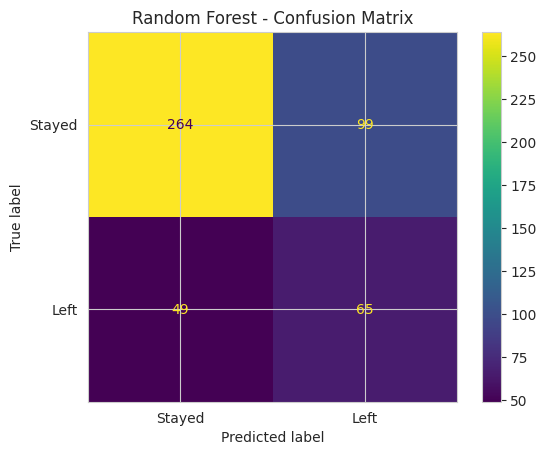

In [ ]:
#Visualized
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=['Stayed', 'Left']
).plot()

plt.title('Random Forest - Confusion Matrix')
plt.show()

In [ ]:
#Confusion Matrix — AdaBoost
ada_cm = confusion_matrix(y_test, ada_pred)

print("AdaBoost Confusion Matrix:")
print(ada_cm)

AdaBoost Confusion Matrix:
[[204 159]
 [ 23  91]]


<Figure size 600x500 with 0 Axes>

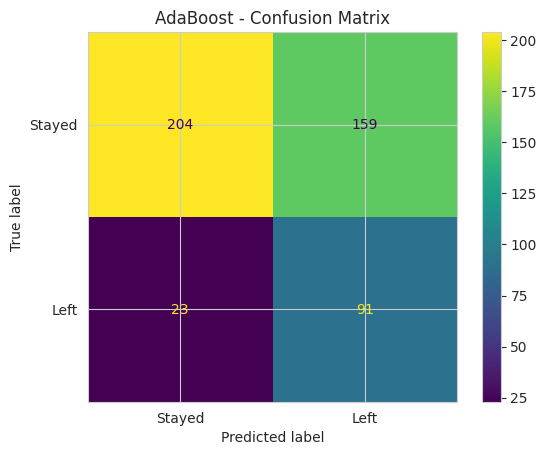

In [ ]:
#Visualized
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay(
    confusion_matrix=ada_cm,
    display_labels=['Stayed', 'Left']
).plot()

plt.title('AdaBoost - Confusion Matrix')
plt.show()

Suppose:

Actual = Left
Predicted = Left

That's:

TP — True Positive

Model correctly predicts that the driver will leave.

✅ Good prediction.

TN — True Negative
Actual = Stayed
Predicted = Stayed

Model correctly predicts that the driver will stay.

✅ Good prediction.

FP — False Positive
Actual = Stayed
Predicted = Left

Model says the driver will leave, but actually they stay.

❌ False alarm.

FN — False Negative
Actual = Left
Predicted = Stayed

Model says the driver will stay, but actually they leave.

❌ Potentially the most costly error for Ola.

Why?

Because Ola may fail to take retention action for a driver who was actually at risk of leaving.

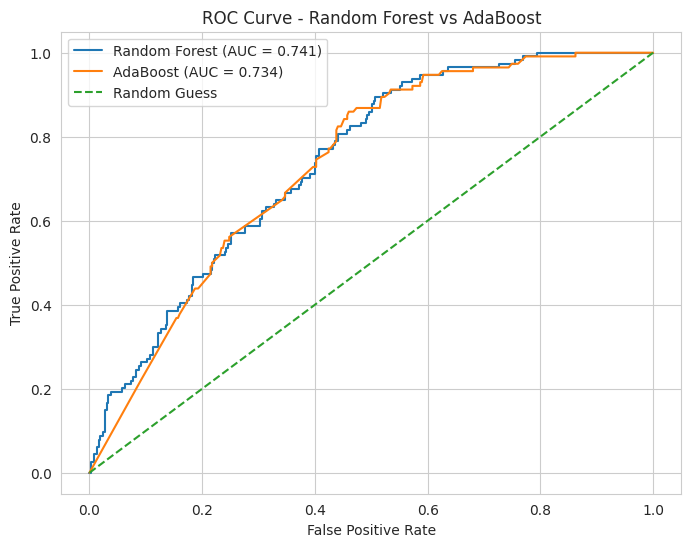

In [ ]:
# Calculate ROC curve values

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
ada_fpr, ada_tpr, _ = roc_curve(y_test, ada_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

plt.plot(
    ada_fpr,
    ada_tpr,
    label=f'AdaBoost (AUC = {ada_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest vs AdaBoost')
plt.legend()
plt.show()

###Insight

Higher AUC = Better ability to distinguish classes

In [ ]:
#Identify the better model
if rf_auc > ada_auc:
    best_model = "Random Forest"
    best_auc = rf_auc
else:
    best_model = "AdaBoost"
    best_auc = ada_auc

print(f"Best model based on ROC-AUC: {best_model}")
print(f"ROC-AUC: {best_auc:.4f}")

Best model based on ROC-AUC: Random Forest
ROC-AUC: 0.7407


In [ ]:
results
print(f"Random Forest ROC-AUC : {rf_auc:.4f}")
print(f"AdaBoost ROC-AUC       : {ada_auc:.4f}")

Random Forest ROC-AUC : 0.7407
AdaBoost ROC-AUC       : 0.7343


**Model Evaluation:**

The Random Forest and AdaBoost models were evaluated using classification metrics, confusion matrices, and ROC-AUC. Precision, recall, F1-score, and accuracy were calculated for both the retained and attrition classes. Since the dataset is imbalanced, ROC-AUC and recall for the attrition class were given particular importance. The confusion matrices were used to identify true positives, true negatives, false positives, and false negatives. The ROC curves were plotted to compare the discriminatory ability of the two ensemble models. The final model should be selected based not only on overall ROC-AUC but also on its ability to correctly identify drivers who are likely to leave.

#Q5 - Actionable Insights & Recommendations

In [ ]:
rf_importance.head(15)

,Feature,Importance
11,Tenure_Days,0.18
12,Tenure_Months,0.18
8,Quarterly Rating,0.12
7,Total Business Value,0.11
6,Grade,0.06
0,Driver_ID,0.05
4,Income,0.05
9,Quarterly_Rating_Increased,0.05
1,Age,0.04
5,Joining Designation,0.04


In [ ]:
ada_importance.head(15)


,Feature,Importance
11,Tenure_Days,0.31
12,Tenure_Months,0.28
8,Quarterly Rating,0.17
7,Total Business Value,0.12
9,Quarterly_Rating_Increased,0.09
1,Age,0.01
6,Grade,0.01
3,Education_Level,0.01
27,City_C23,0.01
0,Driver_ID,0.00


#**Recommended business actions**

Now we can formulate the actual recommendations.

🔴 High-risk drivers

For drivers with high predicted attrition probability:

Personalized retention offers
Performance-based incentives
Direct driver-support calls
Investigate dissatisfaction
Flexible incentive schemes
Immediate grievance resolution

🟡 Medium-risk drivers

Regular engagement
Performance monitoring
Targeted incentives
Training/coaching
Early warning notifications

🟢 Low-risk drivers

Continue normal engagement
Recognition/rewards for good performance
Avoid unnecessary incentive spending

This is much more efficient than giving expensive incentives to every driver.

## Actionable Insights and Recommendations

The driver attrition prediction model can be used as an early-warning system to identify drivers who are at a higher risk of leaving Ola. Instead of applying the same retention strategy to all drivers, Ola can use the predicted attrition probability to prioritize high-risk drivers and provide targeted interventions.

### 1. Develop a Driver Attrition Early-Warning System

The selected ensemble model can generate an attrition probability for each active driver. Drivers can be categorized into high-, medium-, and low-risk groups. High-risk drivers should receive immediate retention attention, while medium-risk drivers can be monitored through regular engagement programs.

### 2. Improve Driver Onboarding and Early-Tenure Support

If the analysis indicates higher attrition among newer drivers, Ola should strengthen the onboarding process and provide additional support during the first few months. Training, dedicated support, early incentives, and regular feedback can help improve early-stage retention.

### 3. Introduce Targeted Financial Incentives

If income and business performance are important predictors of attrition, Ola can design targeted incentive programs instead of providing uniform incentives to all drivers. Performance-linked bonuses, temporary earning guarantees, and incentives for meeting business targets can be considered for vulnerable driver segments.

### 4. Support Drivers with Low or Declining Performance

Drivers showing persistently low or declining quarterly ratings can be provided with coaching, training, and operational support. The objective should be to improve performance before dissatisfaction results in attrition.

### 5. Use City-Specific Retention Strategies

Attrition rates may vary considerably across cities. Ola should identify high-attrition locations and investigate local factors such as driver earnings, demand levels, competition, operating costs, incentives, and support quality. Retention strategies should therefore be adapted to local market conditions.

### 6. Retain High-Value and High-Performing Drivers

Drivers who generate high business value or demonstrate strong performance should receive appropriate recognition and retention benefits. Losing experienced and high-performing drivers can have a greater business impact than losing lower-value drivers.

### 7. Monitor Retention Campaign Effectiveness

After implementing retention interventions, Ola should continuously monitor whether targeted drivers remain active. Model predictions and actual driver outcomes can be compared periodically so that the prediction system and retention strategies can be improved over time.

### Overall Business Impact

The key objective is to move from a reactive approach, where Ola responds after a driver leaves, to a predictive approach in which potential attrition is identified in advance. By combining ML-based risk prediction with targeted retention actions, Ola can potentially reduce unnecessary driver acquisition costs, improve driver engagement, and retain valuable drivers more effectively.
